# Loss Functions in Neural Networks
### Mean Squared Error vs Cross-Entropy Loss

**Name:** Syahrul Sardonyx Nalli
**Registration No.:** 2411021240061
**Subject:** Deep Learning

---
**Objective:** Understand how neural networks measure prediction errors by implementing basic loss functions and comparing the difference between actual and predicted values.


## Task 1: Actual Class Labels and Predicted Outputs

We simulate a simple **binary classification problem**.

- `y_true` holds the actual class labels (0 or 1).
- `y_pred_prob` holds the predicted probabilities output by a model (e.g. after a sigmoid activation) — these are needed for Cross-Entropy Loss.
- `y_pred_reg` holds raw predicted values on a continuous scale — used to illustrate MSE in a regression-style setting.


In [1]:
import numpy as np

# Actual class labels (ground truth) for 6 samples
y_true = np.array([1, 0, 1, 1, 0, 0])

# Predicted probabilities from the model (for Cross-Entropy Loss)
y_pred_prob = np.array([0.90, 0.10, 0.80, 0.60, 0.30, 0.20])

# Predicted continuous values, scaled 0-1 (for Mean Squared Error)
y_pred_reg = np.array([0.85, 0.20, 0.75, 0.55, 0.40, 0.10])

print("Actual labels      :", y_true)
print("Predicted probs     :", y_pred_prob)
print("Predicted (for MSE) :", y_pred_reg)


Actual labels      : [1 0 1 1 0 0]
Predicted probs     : [0.9 0.1 0.8 0.6 0.3 0.2]
Predicted (for MSE) : [0.85 0.2  0.75 0.55 0.4  0.1 ]


## Task 2: Calculating MSE and Cross-Entropy Loss

**Mean Squared Error (MSE)** measures the average of the squared differences between actual and predicted values:

MSE = (1/n) * Σ (y_true - y_pred)²

**Cross-Entropy Loss** (binary) measures the difference between two probability distributions — the true labels and the predicted probabilities:

CE = -(1/n) * Σ [ y_true * log(y_pred) + (1 - y_true) * log(1 - y_pred) ]

Both are implemented from scratch below (no library shortcuts), so each step is visible.


In [2]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def cross_entropy_loss(y_true, y_pred, epsilon=1e-12):
    # clip predictions to avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

mse_value = mean_squared_error(y_true, y_pred_reg)
ce_value = cross_entropy_loss(y_true, y_pred_prob)

print(f"Mean Squared Error : {mse_value:.4f}")
print(f"Cross-Entropy Loss : {ce_value:.4f}")


Mean Squared Error : 0.0829
Cross-Entropy Loss : 0.2541


In [3]:
# Per-sample breakdown, for inspection
print(f"{'y_true':>8} {'y_pred(MSE)':>12} {'sq_error':>10} {'y_pred(CE)':>12} {'ce_term':>10}")
for yt, ypm, ypc in zip(y_true, y_pred_reg, y_pred_prob):
    sq_error = (yt - ypm) ** 2
    ypc_clipped = np.clip(ypc, 1e-12, 1 - 1e-12)
    ce_term = -(yt * np.log(ypc_clipped) + (1 - yt) * np.log(1 - ypc_clipped))
    print(f"{yt:8d} {ypm:12.2f} {sq_error:10.4f} {ypc:12.2f} {ce_term:10.4f}")


  y_true  y_pred(MSE)   sq_error   y_pred(CE)    ce_term
       1         0.85     0.0225         0.90     0.1054
       0         0.20     0.0400         0.10     0.1054
       1         0.75     0.0625         0.80     0.2231
       1         0.55     0.2025         0.60     0.5108
       0         0.40     0.1600         0.30     0.3567
       0         0.10     0.0100         0.20     0.2231


### Visual Comparison

The charts below make the difference between the two loss functions easier to see at a glance: how each one scores every sample, and how the two overall loss values stack up against each other.

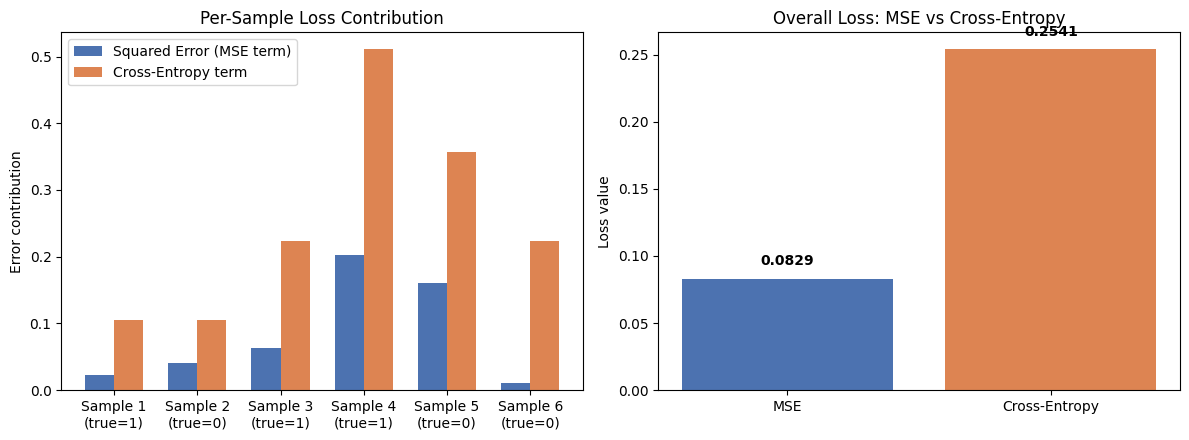

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Left: per-sample error comparison ---
x = np.arange(len(y_true))
width = 0.35
sq_errors = (y_true - y_pred_reg) ** 2
y_pred_prob_clipped = np.clip(y_pred_prob, 1e-12, 1 - 1e-12)
ce_terms = -(y_true * np.log(y_pred_prob_clipped) + (1 - y_true) * np.log(1 - y_pred_prob_clipped))

axes[0].bar(x - width/2, sq_errors, width, label="Squared Error (MSE term)", color="#4C72B0")
axes[0].bar(x + width/2, ce_terms, width, label="Cross-Entropy term", color="#DD8452")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Sample {i+1}\n(true={t})" for i, t in enumerate(y_true)])
axes[0].set_ylabel("Error contribution")
axes[0].set_title("Per-Sample Loss Contribution")
axes[0].legend()

# --- Right: overall loss value comparison ---
axes[1].bar(["MSE", "Cross-Entropy"], [mse_value, ce_value], color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("Loss value")
axes[1].set_title("Overall Loss: MSE vs Cross-Entropy")
for i, v in enumerate([mse_value, ce_value]):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


## Task 3: Comparing the Results

| Aspect | Mean Squared Error | Cross-Entropy Loss |
|---|---|---|
| Measures | Squared numeric distance between actual and predicted values | Divergence between true and predicted probability distributions |
| Best suited for | Regression problems (continuous output) | Classification problems (probabilistic output) |
| Penalty behaviour | Penalises large errors heavily, but treats all magnitudes smoothly | Penalises confident *wrong* predictions very heavily (log term grows sharply near 0) |
| Output range of predictions | Any real number | Probabilities between 0 and 1 |
| Typical final-layer activation | Linear | Sigmoid (binary) / Softmax (multi-class) |

**Observation from our computed values:** Cross-Entropy Loss reacts more sharply to predictions that are confidently wrong (for example, predicting 0.20 when the true label is 1), while MSE changes more gradually as the distance between actual and predicted values grows.

**When to use which:**
- Use **MSE** when the output is a continuous number — e.g. predicting house prices, temperature, or stock values.
- Use **Cross-Entropy Loss** when the output is a class probability — e.g. spam detection, image classification, sentiment analysis.

Using MSE for a classification task is possible but generally performs worse, because it does not penalise confidently wrong predictions as strongly as Cross-Entropy does, which makes training slower to correct serious mistakes.


## Conclusion

Loss functions are at the core of how a neural network learns — they quantify how far off a prediction is from the actual value so that the model can adjust its weights accordingly. Mean Squared Error is suited to regression tasks where outputs are continuous, while Cross-Entropy Loss is suited to classification tasks where outputs are probabilities. Choosing the right loss function is essential for training a model effectively.